In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from DNAnet.data.data_models.hid_image import HIDImage
from DNAnet.data.data_models.dna_models import Panel

from DNAnet.data.parsing import get_peak_data
from DNAnet.evaluation.visualizations import plot_profile
from DNAnet.data.data_models.dna_models import Annotation
from DNAnet.evaluation.visualizations import plot_profile_markers


import matplotlib.pyplot as plt
import numpy as np

# Create HID Image

In [3]:


gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
ppf6_panel_path = "resources/data/SGPanel_PPF6C_SPOOR.xml"

nfi_path = "resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 1/Inj5 2017-05-01-09-45-24-128/1A2_A01_01.hid"
ppf6_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USABLE - HID & PPF6 & GT (but in single_source ds) & PNL  - NIST Mixture_Profiles/Promega_PowerPlex_Fusion_6C/PPF6C_A1_3P-A_1-1-98_0.25_A01_01.hid"
gf_path = '/Users/amarmesic/Documents/tudelft/thesis/datasets/PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/B06_RD14-0003-48_49-1;4-M3c-0.075GF-Q0.8_02.5sec.hid'
local_gf_path = 'resources/data/ProvedIt/A02_RD14-0003-31_32-1;1-M2c-0.03GF-Q2.0_01.15sec.hid'

image = HIDImage(
    path=local_gf_path,
    panel=Panel(gf_panel_path),
    size_standard="GENESCAN_600_LIZ",
)

In [4]:
from config_io import load_model

unet_model = load_model("config/models/unet.yaml")
unet_model.load("resources/model/current_best_unet/")
predictions = unet_model.predict_batch([image])

/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-08-12 23:08:50 INFO     Using device: cpu
2025-08-12 23:08:58 INFO     Calling alleles from predicted segmentation...


In [5]:
image.data.shape, predictions[0].image.shape

((5, 4096, 1), (5, 4096, 1))

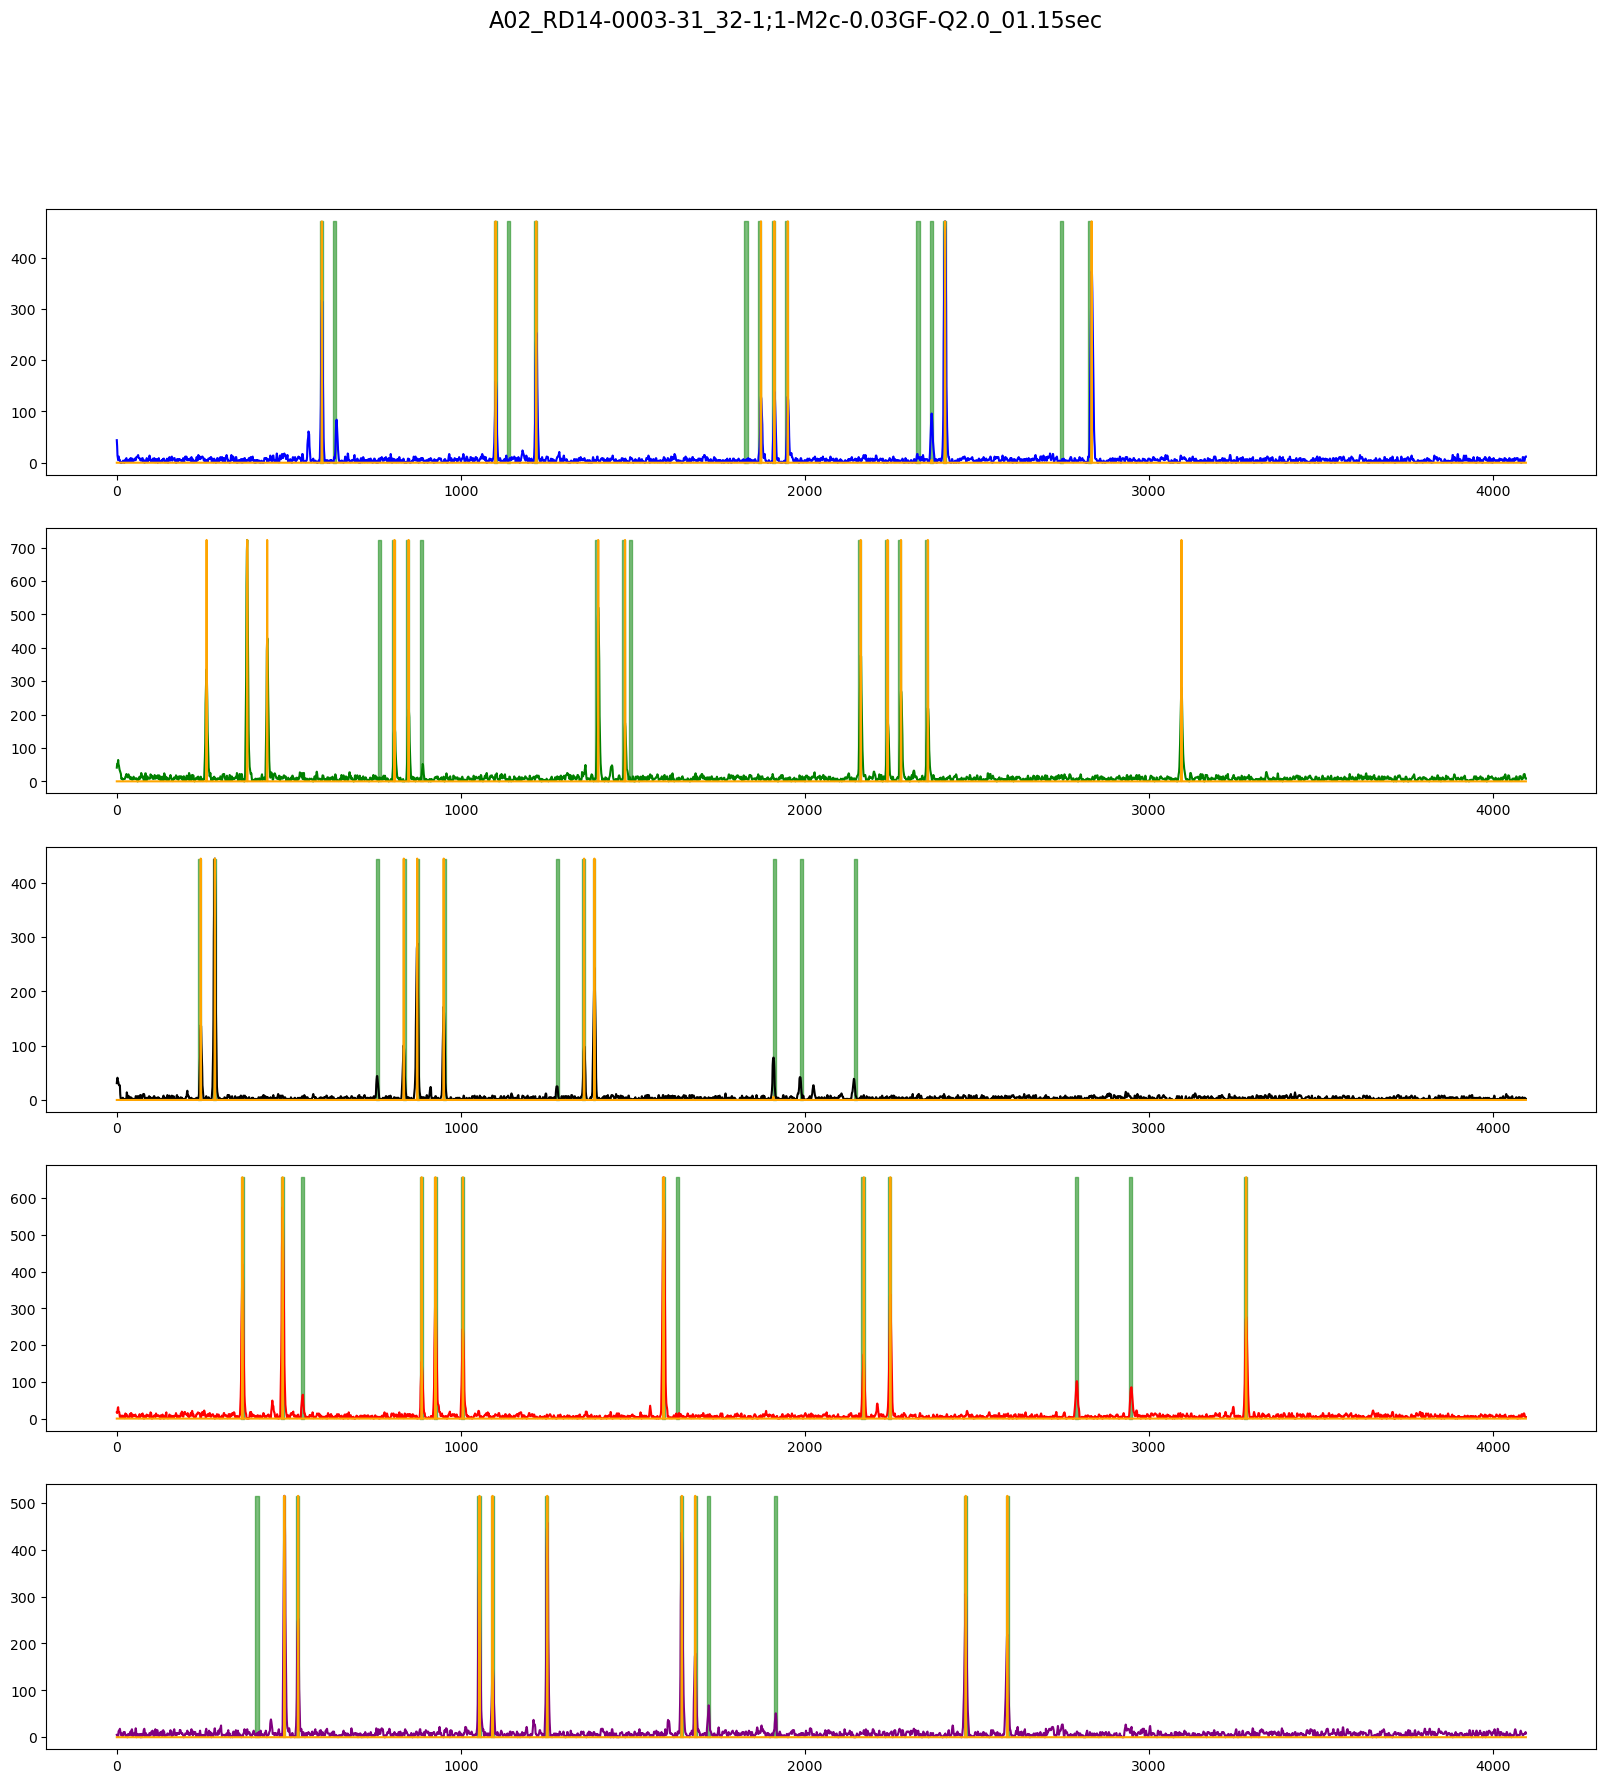

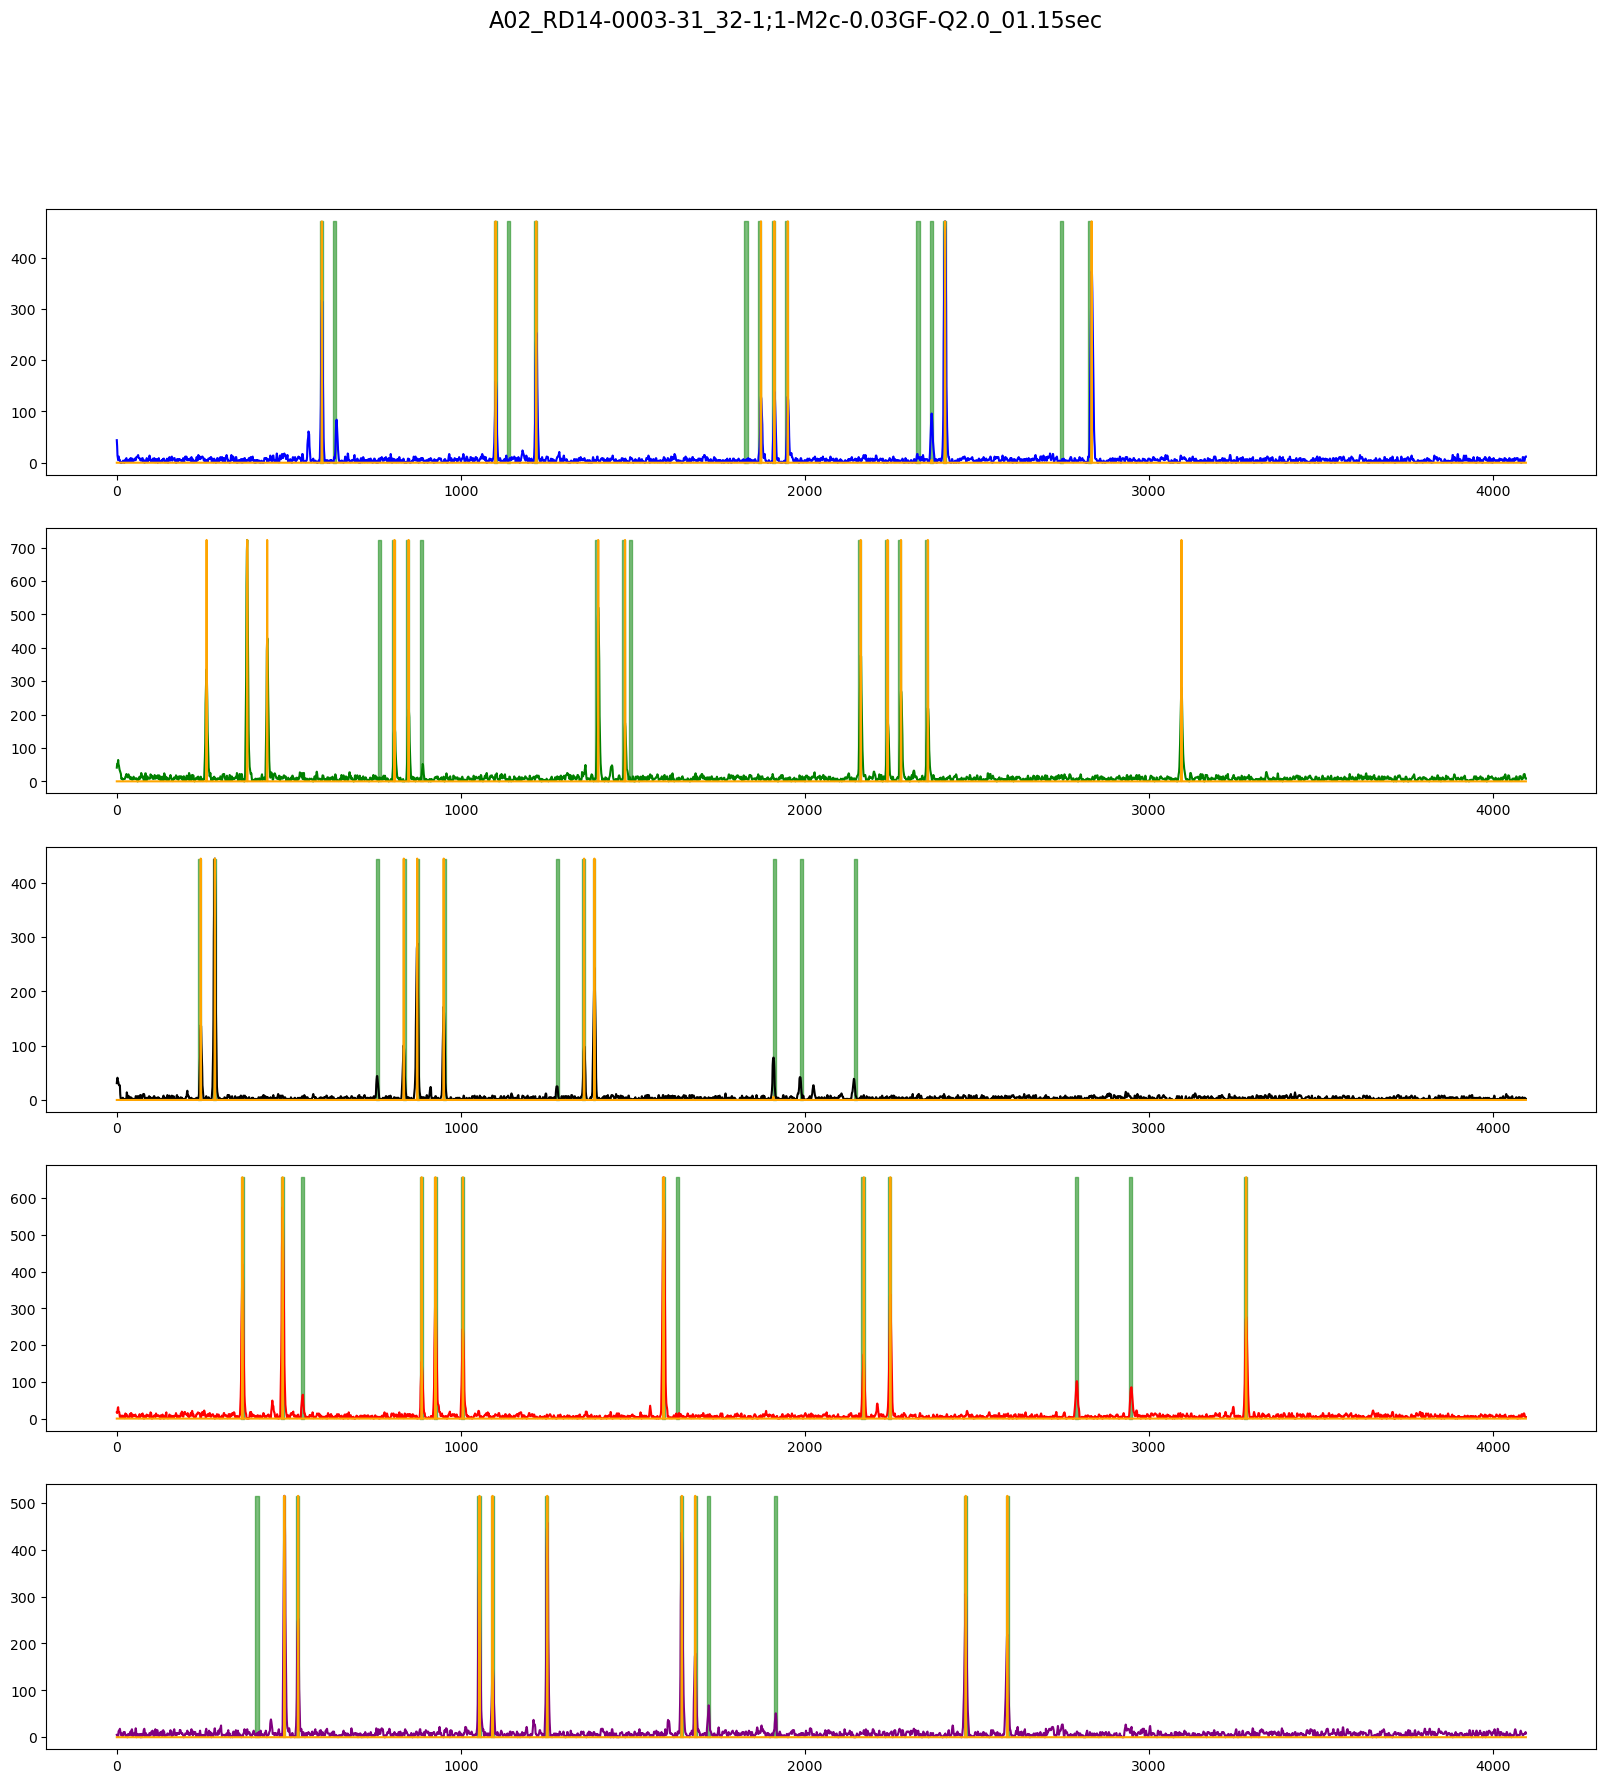

In [6]:
plot_profile([image], predictions, prediction_as_mask=False)

In [7]:
predictions[0]

Prediction(classification=None, image=[[[1.2511980e-06]
  [2.2093190e-08]
  [6.9274591e-07]
  ...
  [3.1752097e-05]
  [5.1024026e-06]
  [1.0248265e-05]]

 [[3.1089289e-07]
  [3.3571990e-08]
  [7.3502918e-07]
  ...
  [4.4682292e-06]
  [7.1233990e-06]
  [1.1002903e-06]]

 [[1.2826222e-06]
  [5.7375422e-07]
  [4.0494433e-07]
  ...
  [1.4940798e-06]
  [3.2330627e-06]
  [2.6425806e-07]]

 [[1.0013875e-05]
  [5.1332012e-07]
  [1.6036581e-06]
  ...
  [1.7641532e-06]
  [1.7831959e-06]
  [1.0130523e-06]]

 [[2.9147911e-06]
  [8.6864014e-07]
  [2.3432729e-06]
  ...
  [3.8676667e-06]
  [8.4025105e-06]
  [1.3631021e-07]]], meta={'original_image_path': PosixPath('resources/data/ProvedIt/A02_RD14-0003-31_32-1;1-M2c-0.03GF-Q2.0_01.15sec.hid'), 'called_alleles': [Marker(dye_row=0, name='D3S1358', alleles=[Allele(name='15', base_pair=None, left_bin=None, right_bin=None, height=317)]), Marker(dye_row=0, name='vWA', alleles=[Allele(name='18', base_pair=None, left_bin=None, right_bin=None, height=254), Al

In [8]:
from DNAnet.evaluation.segmentation.allele_metrics import allele_f1_score, allele_precision, allele_recall

hid_dataset = [image]

print('allele u-net f1: ', allele_f1_score(hid_dataset, predictions))
print('allele u-net precision: ', allele_precision(hid_dataset, predictions))
print('allele u-net recall: ', allele_recall(hid_dataset, predictions))

allele u-net f1:  0.7663551401869159
allele u-net precision:  0.9111111111111111
allele u-net recall:  0.6612903225806451
